Supermarket Sales

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
data=pd.read_csv("Ecommerce_Sales_Data_2024_2025.csv")

In [ ]:
data.shape

(5000, 14)

In [ ]:
data.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB


In [ ]:
data.isnull().sum()

,0
Order ID,0
Order Date,0
Customer Name,0
Region,0
City,0
Category,0
Sub-Category,0
Product Name,0
Quantity,0
Unit Price,0


In [ ]:
data.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000


In [ ]:
data.head(3)

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.dtypes

,0
Order ID,int64
Order Date,object
Customer Name,object
Region,object
City,object
Category,object
Sub-Category,object
Product Name,object
Quantity,int64
Unit Price,int64


## Data Cleaning
In this section, we clean the dataset by checking for duplicates, missing values, incorrect data types, and formatting issues to ensure the data is ready for analysis.

In [22]:
data.columns=data.columns.str.strip()
data.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode'],
      dtype='object')

In [21]:
data["Order Date"]=pd.to_datetime(data["Order Date"])
data["Order Date"].dtype

dtype('<M8[ns]')

In [20]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [19]:
data.dtypes

,0
Order ID,int64
Order Date,object
Customer Name,object
Region,object
City,object
Category,object
Sub-Category,object
Product Name,object
Quantity,int64
Unit Price,int64


In [17]:
data.to_csv("Cleaned_Ecommerce_Sales_Data_2024_2025.csv", index=False)

Cleaning is done


In [23]:
data["Year"]=data["Order Date"].dt.year
data["Month"]=data["Order Date"].dt.month
data["Month Name"]=data["Order Date"].dt.month_name()
data["Day"]=data["Order Date"].dt.day
data["weekday"]=data["Order Date"].dt.day_name()

In [ ]:
data.dtypes

,0
Order ID,int64
Order Date,datetime64[ns]
Customer Name,object
Region,object
City,object
Category,object
Sub-Category,object
Product Name,object
Quantity,int64
Unit Price,int64


In [ ]:
data.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,Year,Month,Month Name,Day,weekday
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card,2024,10,October,19,Saturday
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card,2025,8,August,30,Saturday
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card,2023,11,November,4,Saturday
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI,2025,5,May,23,Friday
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card,2025,1,January,19,Sunday


In [ ]:
data.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

In this section, we analyze the cleaned dataset to identify trends, patterns, and business insights using descriptive statistics and data visualizations.

In [ ]:
data.head(3)

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,Year,Month,Month Name,Day,weekday
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card,2024,10,October,19,Saturday
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card,2025,8,August,30,Saturday
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card,2023,11,November,4,Saturday


In [ ]:
print(f"Total Sales: {data['Sales'].sum():,.2f}")
print(f"Total Profit: {data["Profit"].sum():,.2f}")
print(f"Total Orders: {data["Order ID"].nunique()}")

Total Sales: 533,666,024.35
Total Profit: 79,708,734.91
Total Orders: 5000


In [ ]:
category_sales=(data.groupby("Category")["Sales"].sum().sort_values(ascending=False))
category_sales

,Sales
Category,
Home Decor,57233222.35
Furniture,56647187.90
Clothing,55053908.30
Books,54932643.00
Kitchen,54227902.30
Electronics,52587883.95
Toys,52227366.45
Sports,52069397.25
Beauty,50803409.70


In [ ]:
region_sales=(data.groupby("Region")["Sales"].sum().sort_values(ascending=False))
region_sales

,Sales
Region,
North,1.435782e+08
East,1.358116e+08
West,1.310460e+08
South,1.232302e+08


In [ ]:
city_sales=(data.groupby("City")["Sales"].sum().sort_values(ascending=False))
city_sales

,Sales
City,
Bangalore,29989840.85
Lucknow,29901483.40
Guwahati,29606888.90
Chandigarh,29331057.35
Jaipur,29319402.90
Amritsar,28746184.20
Surat,28532934.65
Patna,27702815.20
Bhubaneswar,27088786.45


In [ ]:
data["Payment Mode"].value_counts()

,count
Payment Mode,
Net Banking,1010
COD,1005
Debit Card,1003
Credit Card,994
UPI,988


In [ ]:
monthly_sales=data.groupby("Month Name")["Sales"].sum()
monthly_sales

,Sales
Month Name,
April,43868599.00
August,46617810.70
December,45431026.65
February,39755842.60
January,42998043.20
July,46545851.45
June,42524458.70
March,44174004.10
May,50755715.20


In [ ]:
top_mafsulotlar=data.groupby("Product Name")["Sales"].sum().sort_values().head(7)
top_mafsulotlar

,Sales
Product Name,
Bed Esse,264.10
Face Cream Amet,265.05
Textbook Commodi,269.45
Action Figure Dolores,330.30
Bed Ipsam,362.10
Mixer Grinder Deleniti,374.40
Puzzle Occaecati,566.10


In [ ]:
ozgargan_foyda=data.groupby("Discount")[["Sales", "Profit"]].mean()
ozgargan_foyda

,Sales,Profit
Discount,,
0,117340.715431,17301.211122
5,114617.711759,17442.927331
10,108404.868529,16237.786882
15,98967.904730,14828.028087
20,94618.464251,13951.468217


In [ ]:
data.head(3)

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,Year,Month,Month Name,Day,weekday
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card,2024,10,October,19,Saturday
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card,2025,8,August,30,Saturday
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card,2023,11,November,4,Saturday


In [ ]:
categoriya_foyda=data.groupby("Category")["Sales"].sum().sort_values()
categoriya_foyda

,Sales
Category,
Groceries,47883103.15
Beauty,50803409.70
Sports,52069397.25
Toys,52227366.45
Electronics,52587883.95
Kitchen,54227902.30
Books,54932643.00
Clothing,55053908.30
Furniture,56647187.90


In [ ]:
data.groupby("Quantity")["Sales"].sum()

,Sales
Quantity,
1,3.691501e+07
2,7.027557e+07
3,1.058539e+08
4,1.471421e+08
5,1.734795e+08


# Data Visualization

This section presents visualizations that help understand sales performance, customer behavior, and business trends using Matplotlib.

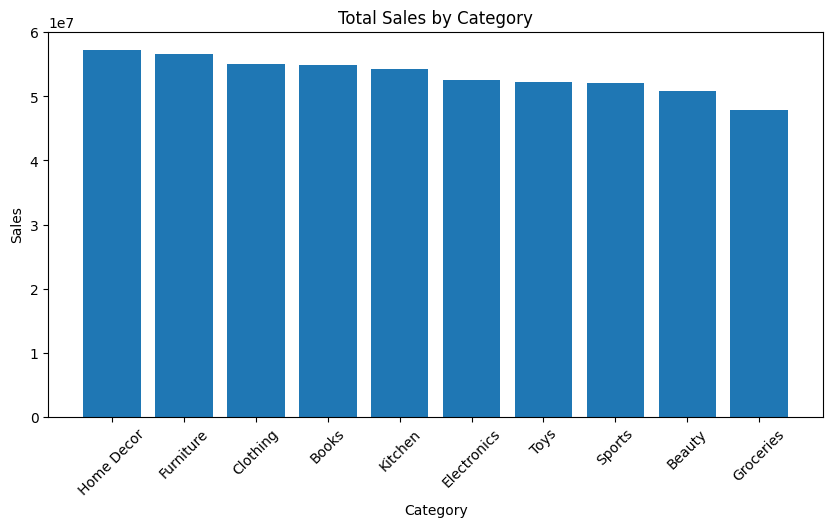

In [ ]:
category_sales = data.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(category_sales.index, category_sales.values)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

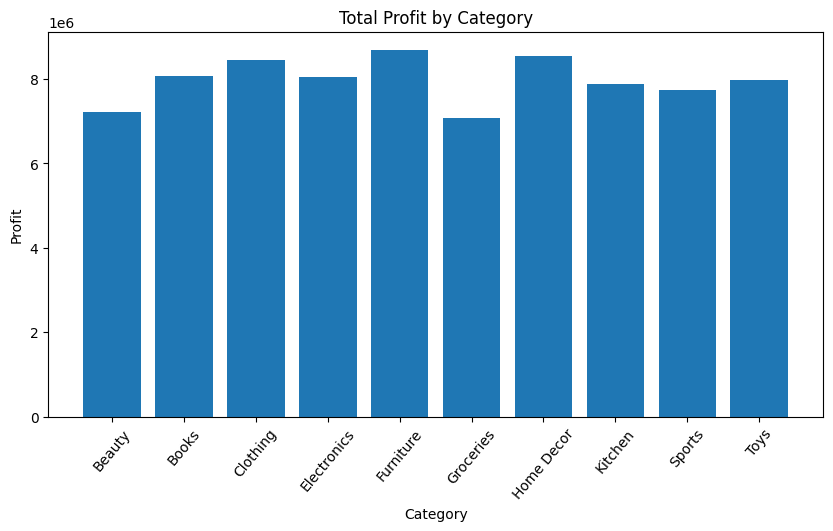

In [ ]:
categoriya_foydam=data.groupby("Category")["Profit"].sum()
plt.figure(figsize=(10,5))
plt.bar(categoriya_foydam.index, categoriya_foydam.values)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=50)
plt.show()

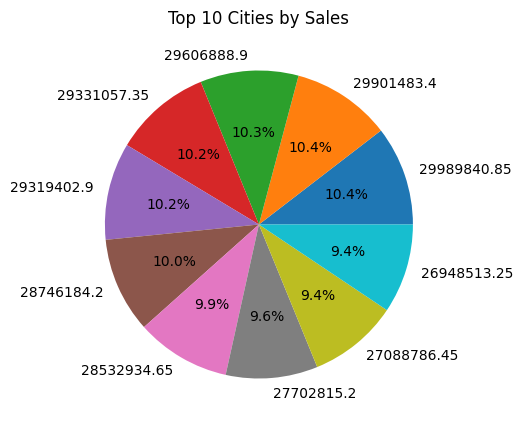

In [ ]:
top_city_ten=data.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.pie(top_city_ten.values, labels=top_city_ten.values, autopct="%1.1f%%")

plt.title("Top 10 Cities by Sales")
plt.show()

In [7]:
data.head(3)

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card


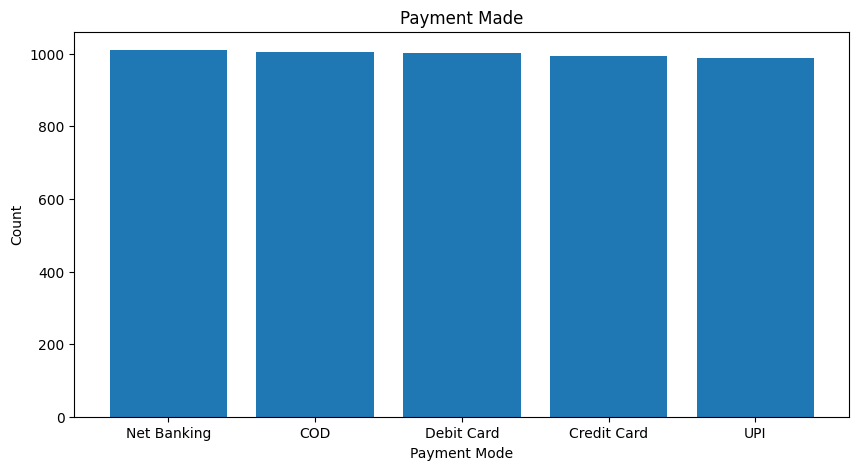

In [15]:
payment=data["Payment Mode"].value_counts()
plt.figure(figsize=(10,5))
plt.bar(payment.index, payment.values)

plt.title("Payment Made")
plt.xlabel("Payment Mode")
plt.ylabel("Count")
plt.show()


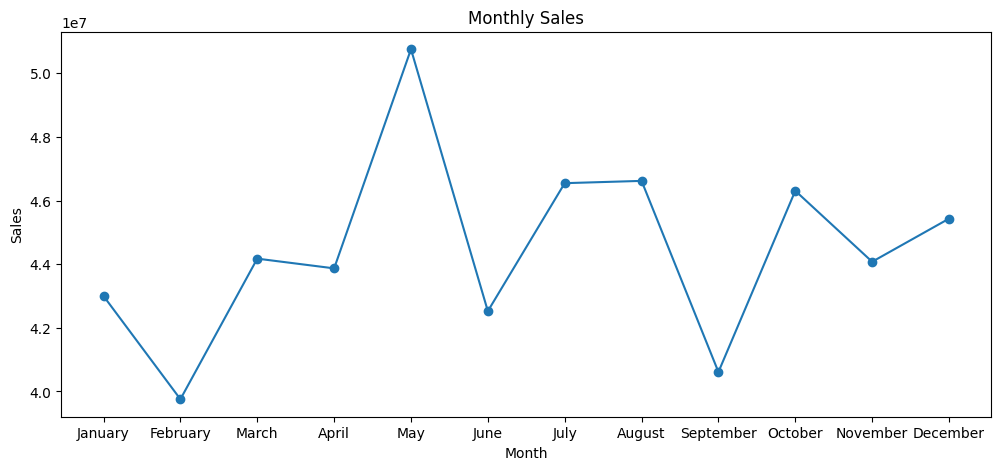

In [27]:
monthly_sale=data.groupby(["Month", "Month Name"])["Sales"].sum().reset_index().sort_values("Month")
plt.figure(figsize=(12,5))
plt.plot(monthly_sale["Month Name"], monthly_sale["Sales"], marker="o")

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


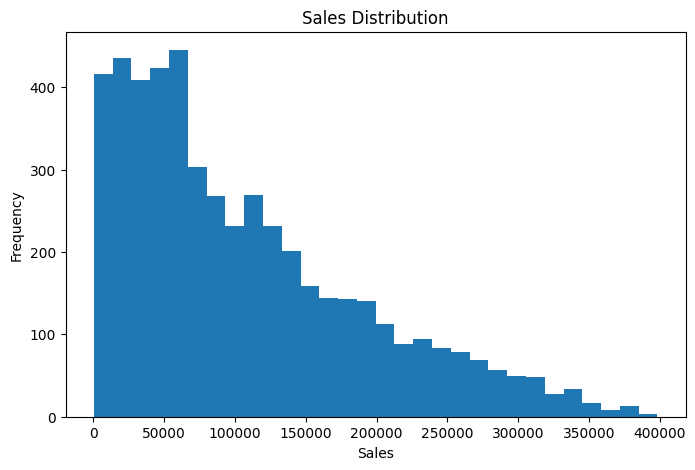

In [28]:
plt.figure(figsize=(8,5))
plt.hist(data["Sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

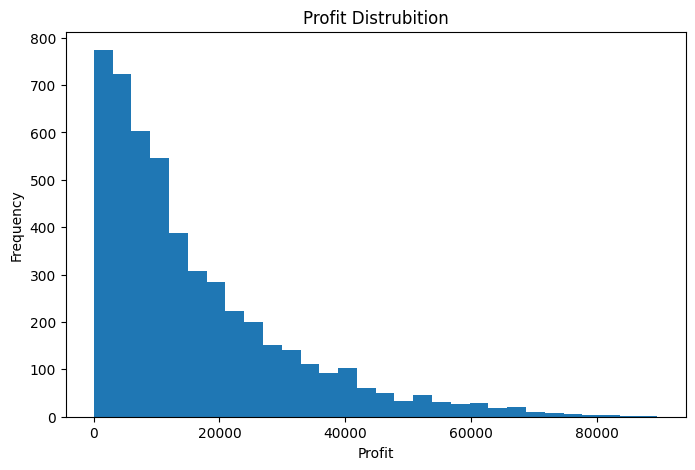

In [30]:
plt.figure(figsize=(8,5))
plt.hist(data["Profit"], bins=30)

plt.title("Profit Distrubition")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

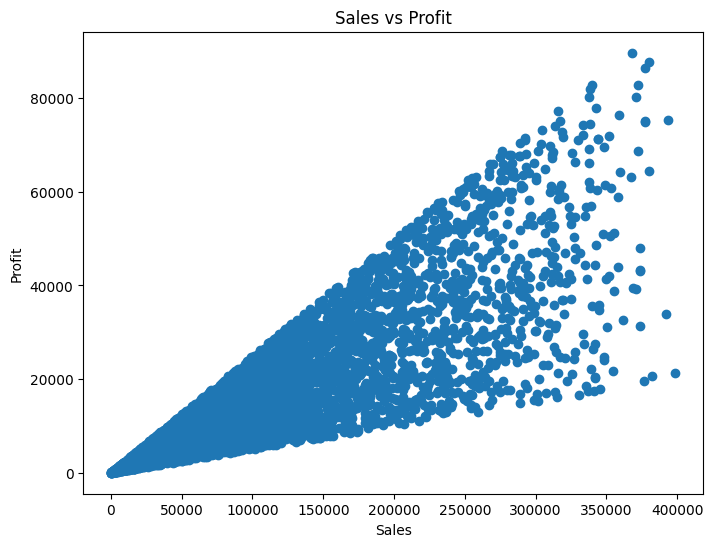

In [32]:
plt.figure(figsize=(8,6))
plt.scatter(data["Sales"], data["Profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

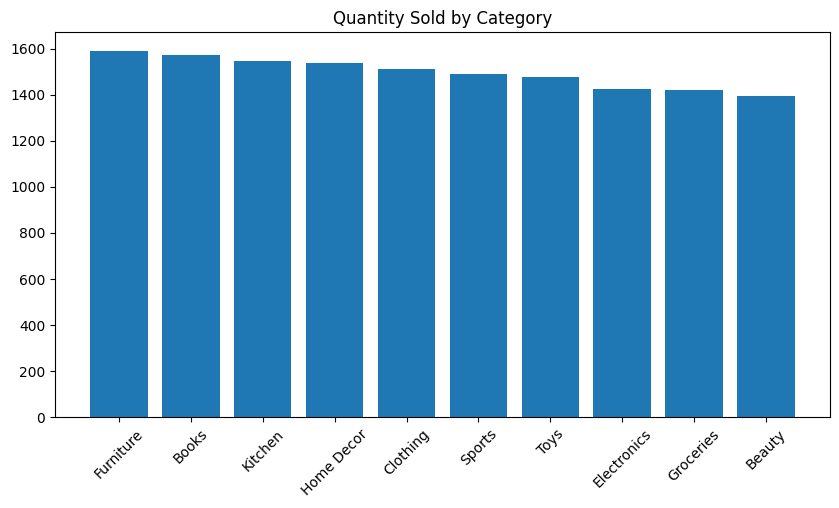

In [33]:
quantity = (
    data.groupby("Category")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
plt.bar(quantity.index,
        quantity.values)

plt.title("Quantity Sold by Category")
plt.xticks(rotation=45)

plt.show()

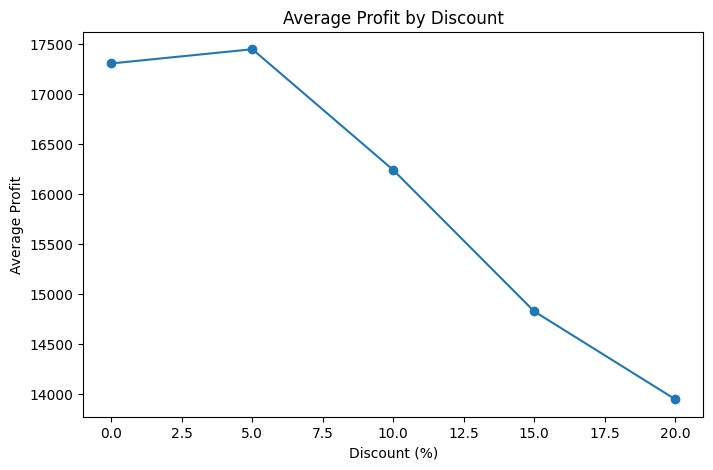

In [34]:
discount = (
    data.groupby("Discount")["Profit"]
      .mean()
)

plt.figure(figsize=(8,5))
plt.plot(discount.index,
         discount.values,
         marker="o")

plt.title("Average Profit by Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Average Profit")

plt.show()